/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5888/3219523174.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


                                                 text  Cluster
0   0061.mp4 Remove the man on the left side (00:0...        1
1   0062.mp4 Duplicate random frames in between to...        2
2   0063.mp4 Remove the dog and the leash (01:07 -...        1
3   0064.mp4 Cut short to 2 seconds by speeding up...        2
4   0065.mp4 Duplicate frames and make the video 1...        2
5   0066.mp4 Remove the guy standing on the left (...        1
6   0067.mp4 Remove the two people standing in the...        1
7   0068.mp4 Remove the groom from the video (01:4...        1
8   0069.mp4 Duplicate frames to make it seem like...        2
9   0070.mp4 Remove the guy in green shirt (01:30 ...        1
10  0071.mp4 Around 0:42, there is a person is a b...        1
11  0072.mp4 Insert the person working out in aux9...        1
12  0073.mp4 Person at 1:53 in (aux10.mp4)https://...        1
13  0074.mp4 Add a stationary car at 1:00 to 1:06 ...        1
14  0075.mp4 From 2:33 to 2:43 repeat some of the ...  

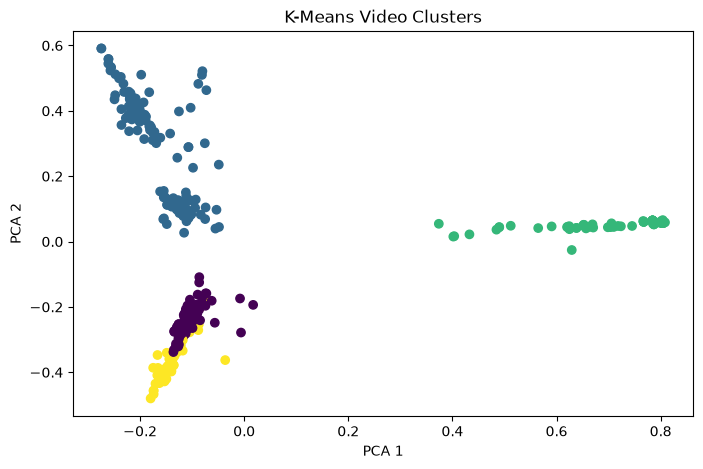


Done! Results saved.


In [1]:
# 1. Import libraries
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("VideoSourceandEdits.csv")

# 3. Select text columns and combine them
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").agg(" ".join, axis=1)

# 4. NLP text cleaning
def clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return " ".join(text.split())

df["clean_text"] = df["text"].apply(clean)

# 5. Convert text to TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=3000)
X = tfidf.fit_transform(df["clean_text"])

# 6. K-Means clustering
k = 4
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# 7. Show results
print(df[["text", "Cluster"]].head(20))

# 8. Show important words in each cluster
words = tfidf.get_feature_names_out()

for i in range(k):
    top = model.cluster_centers_[i].argsort()[-10:][::-1]
    print(f"\nCluster {i}:")
    print(", ".join(words[top]))

# 9. Visualise clusters
pca = PCA(n_components=2, random_state=42)
points = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,5))
plt.scatter(points[:,0], points[:,1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Video Clusters")
plt.show()

# 10. Save results
df.to_csv("VideoSourceandEdits_clustered.csv", index=False)
print("\nDone! Results saved.")